Import Library

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Import Data

In [3]:
data = pd.read_csv('Unsupervised.csv')
data = data.drop(['C_Occasion', 'T_Occasion'], axis=1)

In [4]:
data.info()
print('='*50)
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   C_Fresh_Taste   167 non-null    int64
 1   C_Intense       167 non-null    int64
 2   C_Smooth        167 non-null    int64
 3   C_Acidic        167 non-null    int64
 4   C_Aroma         167 non-null    int64
 5   C_Alert         167 non-null    int64
 6   C_Origin        167 non-null    int64
 7   C_Portable      167 non-null    int64
 8   C_Value         167 non-null    int64
 9   C_Nutrition     167 non-null    int64
 10  C_Brand_Trust   167 non-null    int64
 11  C_Premium_Look  167 non-null    int64
 12  T_Aroma         167 non-null    int64
 13  T_Intense       167 non-null    int64
 14  T_No_Sugar      167 non-null    int64
 15  T_Zero_Cal      167 non-null    int64
 16  T_Nutrition     167 non-null    int64
 17  T_Origin        167 non-null    int64
 18  T_Brew_Method   167 non-null  

,C_Fresh_Taste,C_Intense,C_Smooth,C_Acidic,C_Aroma,C_Alert,C_Origin,C_Portable,C_Value,C_Nutrition,...,T_Aroma,T_Intense,T_No_Sugar,T_Zero_Cal,T_Nutrition,T_Origin,T_Brew_Method,T_Portable,T_Brand_Trust,T_Premium_Look
0,3,3,3,3,3,3,3,3,3,3,...,3,3,4,3,3,3,3,4,3,3
1,5,3,5,3,3,3,3,3,3,3,...,4,4,5,5,4,4,3,5,3,5
2,1,1,5,1,2,5,1,2,2,2,...,4,2,1,1,1,1,1,3,1,3
3,5,5,5,1,5,3,2,3,1,3,...,5,5,5,5,3,2,2,3,3,4
4,4,4,5,2,4,4,4,5,4,5,...,4,4,3,3,3,4,3,4,5,4


In [5]:
data.describe().round(2)

,C_Fresh_Taste,C_Intense,C_Smooth,C_Acidic,C_Aroma,C_Alert,C_Origin,C_Portable,C_Value,C_Nutrition,...,T_Aroma,T_Intense,T_No_Sugar,T_Zero_Cal,T_Nutrition,T_Origin,T_Brew_Method,T_Portable,T_Brand_Trust,T_Premium_Look
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,...,167.00,167.00,167.00,167.00,167.00,167.00,167.0,167.00,167.00,167.00
mean,2.89,2.63,2.77,1.71,2.86,2.59,2.14,2.78,2.45,2.40,...,3.75,3.54,3.46,3.11,3.11,2.93,2.8,3.53,3.28,3.23
std,2.12,1.98,2.06,1.55,2.09,1.97,1.76,2.05,1.96,1.87,...,1.70,1.66,1.76,1.72,1.64,1.51,1.5,1.65,1.67,1.64
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,3.50,3.00,3.00,2.00,3.00,2.00,2.0,3.00,3.00,3.00
50%,4.00,3.00,4.00,1.00,4.00,3.00,3.00,4.00,3.00,3.00,...,4.00,4.00,4.00,3.00,3.00,3.00,3.0,4.00,4.00,4.00
75%,5.00,4.00,5.00,3.00,5.00,4.00,4.00,5.00,4.00,4.00,...,5.00,5.00,5.00,5.00,4.00,4.00,4.0,5.00,5.00,4.00
max,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,5.00,...,5.00,5.00,5.00,5.00,5.00,5.00,5.0,5.00,5.00,5.00


Correlation Anlysis

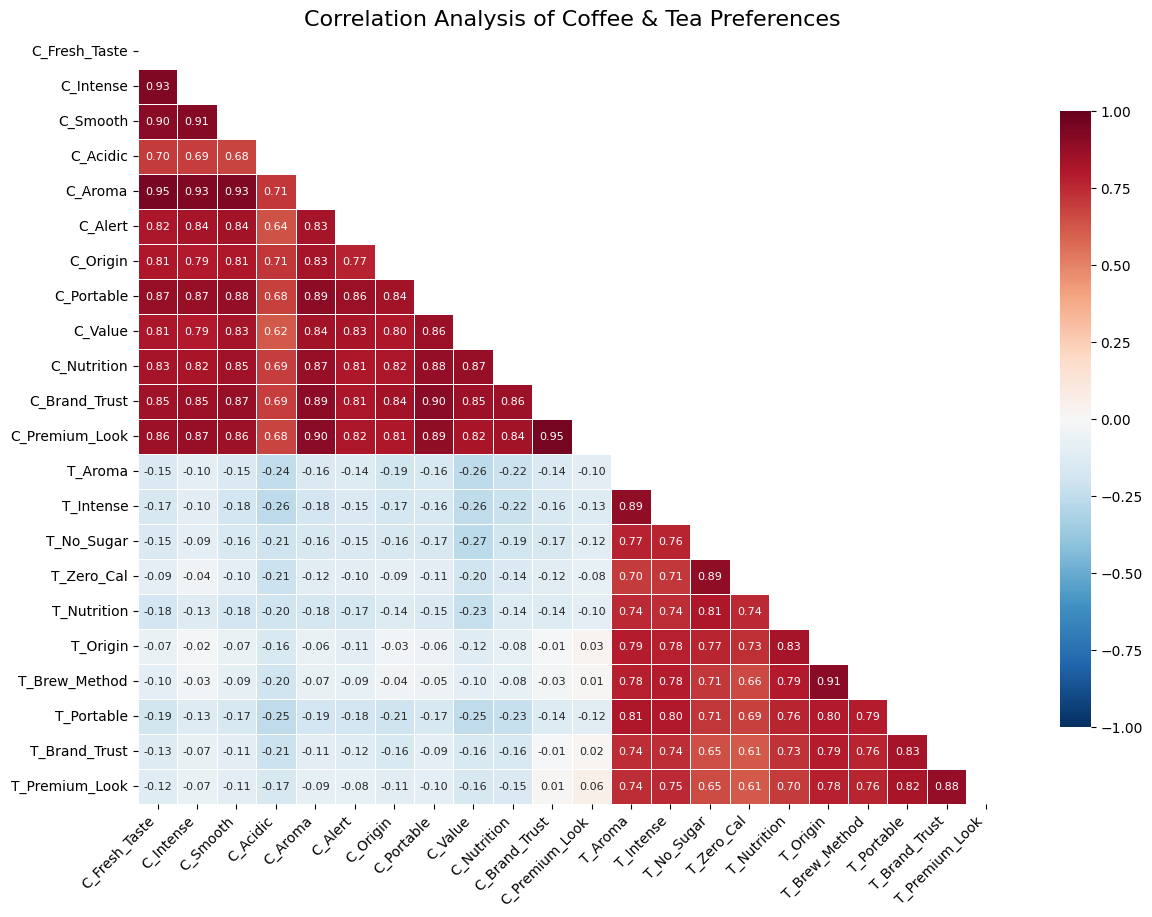

In [ ]:
# คำนวณ Correlation
corr = data.corr()

# สร้าง Mask เพื่อปิดครึ่งบนไม่ให้ข้อมูลซ้ำซ้อน
mask = np.triu(np.ones_like(corr, dtype=bool))

# ตั้งค่ากราฟให้ใหญ่พอสำหรับ 20+ Features
f, ax = plt.subplots(figsize=(14, 10))

# พล็อต Heatmap 
sns.heatmap(corr, 
            mask=mask, 
            cmap='RdBu_r',     
            vmax=1, vmin=-1, 
            center=0,
            annot=True,        
            fmt=".2f",          
            linewidths=.5, 
            cbar_kws={"shrink": .8},
            annot_kws={"size": 8}) 

plt.title('Correlation Analysis of Coffee & Tea Preferences', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.show()

Feaures Scaling

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
data_scaled = pd.DataFrame(data_scaled, columns=data.columns, index=data.index)

data_scaled.head()

,C_Fresh_Taste,C_Intense,C_Smooth,C_Acidic,C_Aroma,C_Alert,C_Origin,C_Portable,C_Value,C_Nutrition,...,T_Aroma,T_Intense,T_No_Sugar,T_Zero_Cal,T_Nutrition,T_Origin,T_Brew_Method,T_Portable,T_Brand_Trust,T_Premium_Look
0,0.053872,0.184760,0.113912,0.835079,0.066245,0.209995,0.492539,0.105274,0.282002,0.321279,...,-0.445527,-0.326318,0.306741,-0.066363,-0.069710,0.047816,0.136580,0.284668,-0.168883,-0.142919
1,1.000888,0.184760,1.089470,0.835079,0.066245,0.209995,0.492539,0.105274,0.282002,0.321279,...,0.144973,0.279183,0.875915,1.100229,0.543003,0.713255,0.136580,0.894149,-0.168883,1.081058
2,-0.893144,-0.826878,1.089470,-0.456201,-0.414750,1.226494,-0.649878,-0.383080,-0.229893,-0.215257,...,0.144973,-0.931820,-1.400782,-1.232955,-1.295136,-1.283062,-1.205121,-0.324813,-1.369034,-0.142919
3,1.000888,1.196399,1.089470,-0.456201,1.028234,0.209995,-0.078669,0.105274,-0.741787,0.321279,...,0.735474,0.884685,0.875915,1.100229,-0.069710,-0.617623,-0.534270,-0.324813,-0.168883,0.469069
4,0.527380,0.690579,1.089470,0.189439,0.547239,0.718245,1.063747,1.081982,0.793896,1.394353,...,0.144973,0.279183,-0.262434,-0.066363,-0.069710,0.713255,0.136580,0.284668,1.031267,0.469069


Anomaly Detection (LOF)

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# กำหนดสัดส่วน Outlier ที่คาดไว้ 5% 
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred = lof.fit_predict(data_scaled) 

# สร้างคอลัมน์เก็บสถานะ
import numpy as np
data_scaled['is_anomaly'] = np.where(y_pred == -1, 1, 0)

print(f"ตรวจพบ Anomaly ทั้งหมด: {data_scaled['is_anomaly'].sum()} รายการ")

ตรวจพบ Anomaly ทั้งหมด: 9 รายการ


Dimensionality Reduction (PCA)

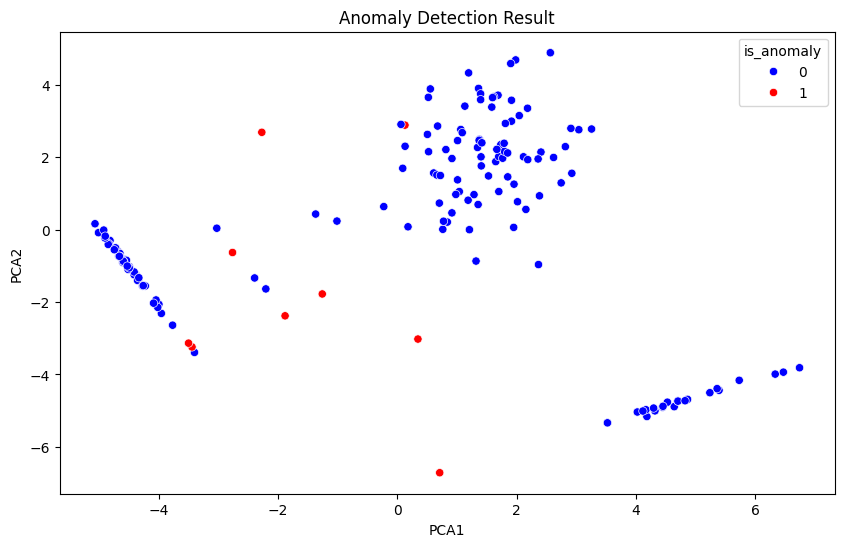

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# ยุบ 22-24 มิติให้เหลือ 2 มิติเพื่อพล็อตกราฟ
pca = PCA(n_components=2)
features_only = data_scaled.drop(columns=['is_anomaly'])
data_pca = pca.fit_transform(features_only)

# เตรียมข้อมูลสำหรับพล็อต
df_plot = pd.DataFrame(data_pca, columns=['PCA1', 'PCA2'])
df_plot['is_anomaly'] = data_scaled['is_anomaly'].values

# พล็อตกราฟ (0=Normal/Blue, 1=Anomaly/Red)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='PCA1', y='PCA2', hue='is_anomaly', palette={0: 'blue', 1: 'red'})
plt.title('Anomaly Detection Result')
plt.show()

# กรองข้อมูลที่สะอาด (Normal เท่านั้น) ไว้ใช้ในขั้นตอน Clustering 
data_for_clustering = data_scaled[data_scaled['is_anomaly'] == 0].drop(columns=['is_anomaly'])

Elbow Method for KMeans

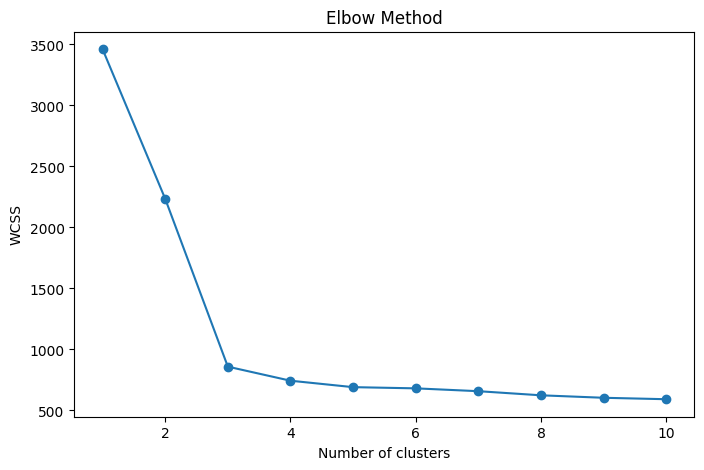

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# ใช้ data_for_clustering ที่เตรียมไว้
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(data_for_clustering)
    wcss.append(kmeans.inertia_)

# พล็อตกราฟ Elbow
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

Clustering (K-Means)

In [ ]:
# Fit KMeans ด้วยข้อมูลที่ไม่มี Anomaly
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans.fit(data_for_clustering)

# Predict และเก็บค่าลงใน data_scaled
data_scaled['Cluster_ID'] = kmeans.predict(data_scaled.drop(columns=['is_anomaly']))

# ตรวจสอบผล
print(data_scaled['Cluster_ID'].value_counts())

Cluster_ID
0    87
2    55
1    25
Name: count, dtype: int64


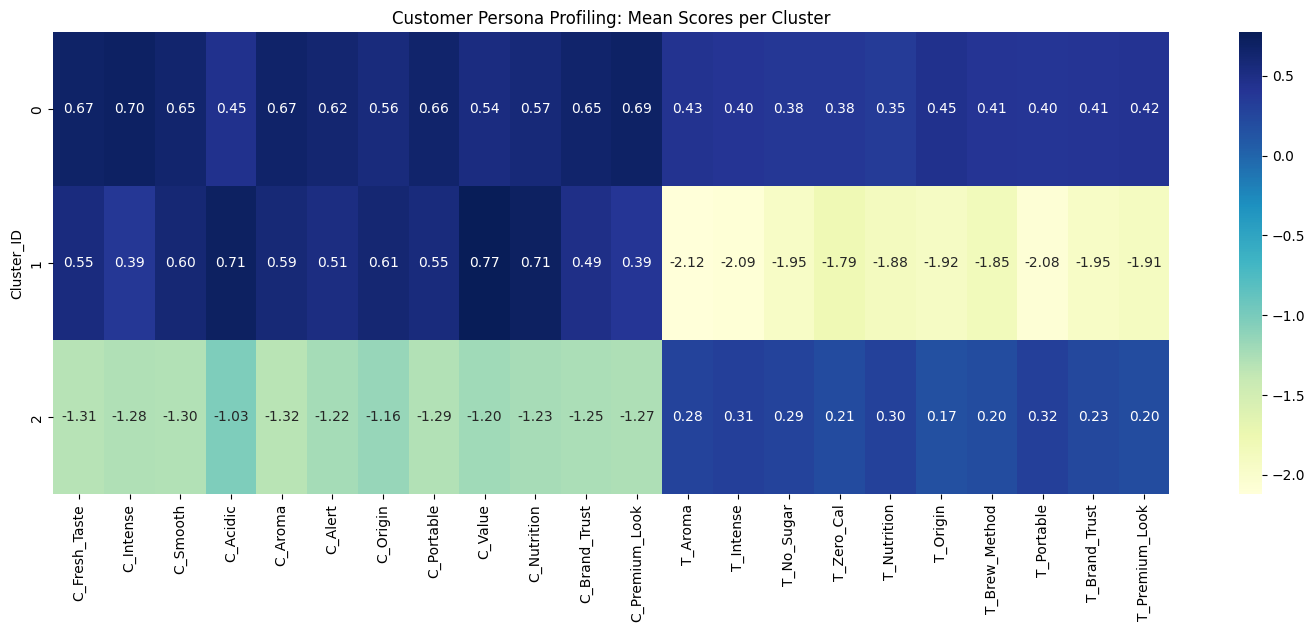

In [ ]:
# กำหนดรายชื่อคอลัมน์ (Features) ที่จะใช้ทำ Profiling 
# โดยเลือกเฉพาะคอลัมน์ที่ขึ้นต้นด้วย C_ (Coffee) และ T_ (Tea) เท่านั้น
feautres = [col for col in data_scaled.columns if col.startswith('C_') or col.startswith('T_')]

# ทำ Profiling โดยการหาค่าเฉลี่ย (Mean) แยกตามกลุ่ม Cluster_ID
cluster_profile = data_scaled.groupby('Cluster_ID')[feautres].mean()

# แสดงผล Heatmap เพื่อวิเคราะห์จุดเด่นของแต่ละกลุ่ม 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))
sns.heatmap(cluster_profile, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Customer Persona Profiling: Mean Scores per Cluster')
plt.show()

In [ ]:
# สร้าง row_id จาก Index เพื่อใช้เป็น Key ในการ Merge ข้อมูล 
data_scaled['row_id'] = data_scaled.index 

# เลือกเฉพาะคอลัมน์สำคัญ
final_unsup_output = data_scaled[['row_id', 'is_anomaly', 'Cluster_ID']]

# Export ไฟล์ CSV 
final_unsup_output.to_csv('unsupervised_results.csv', index=False)
print("Export Unsupervised Results Success!")

Export Unsupervised Results Success!
